# Chest X-Ray Pneumonia Detection Using ANN and CNN

# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
import glob as gb
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
import os
import cv2

# 2. Dataset Loading

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


# 3. Data Analysis and Visualization\

In [3]:
train_dir = path+"/chest_xray/train"
test_dir = path+"/chest_xray/test"
val_dir = path+"/chest_xray/val"

In [4]:
classes = ['NORMAL', 'PNEUMONIA']

for cls in classes:

    imgs = gb.glob(train_dir + f'/{cls}/*.jpeg')

    print(f"{cls} Images Count = {len(imgs)}")

NORMAL Images Count = 1341
PNEUMONIA Images Count = 3875


# 4. Data Preprocessing


In [5]:
IMG_SIZE = 128

X = []
y = []


for cls in classes:

    print(f"Loading {cls} Images...")

    imgs_paths = gb.glob(train_dir + f'/{cls}/*.jpeg')

    for img_path in tqdm(imgs_paths):

        # Read Image
        img = cv2.imread(img_path)

        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Convert to GrayScale
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Normalize
        img = img / 255.0

        X.append(img)

        # Label
        y.append(classes.index(cls))

Loading NORMAL Images...


100%|██████████| 1341/1341 [00:37<00:00, 35.63it/s]


Loading PNEUMONIA Images...


100%|██████████| 3875/3875 [00:51<00:00, 74.81it/s]


In [6]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(5216, 128, 128)
(5216,)


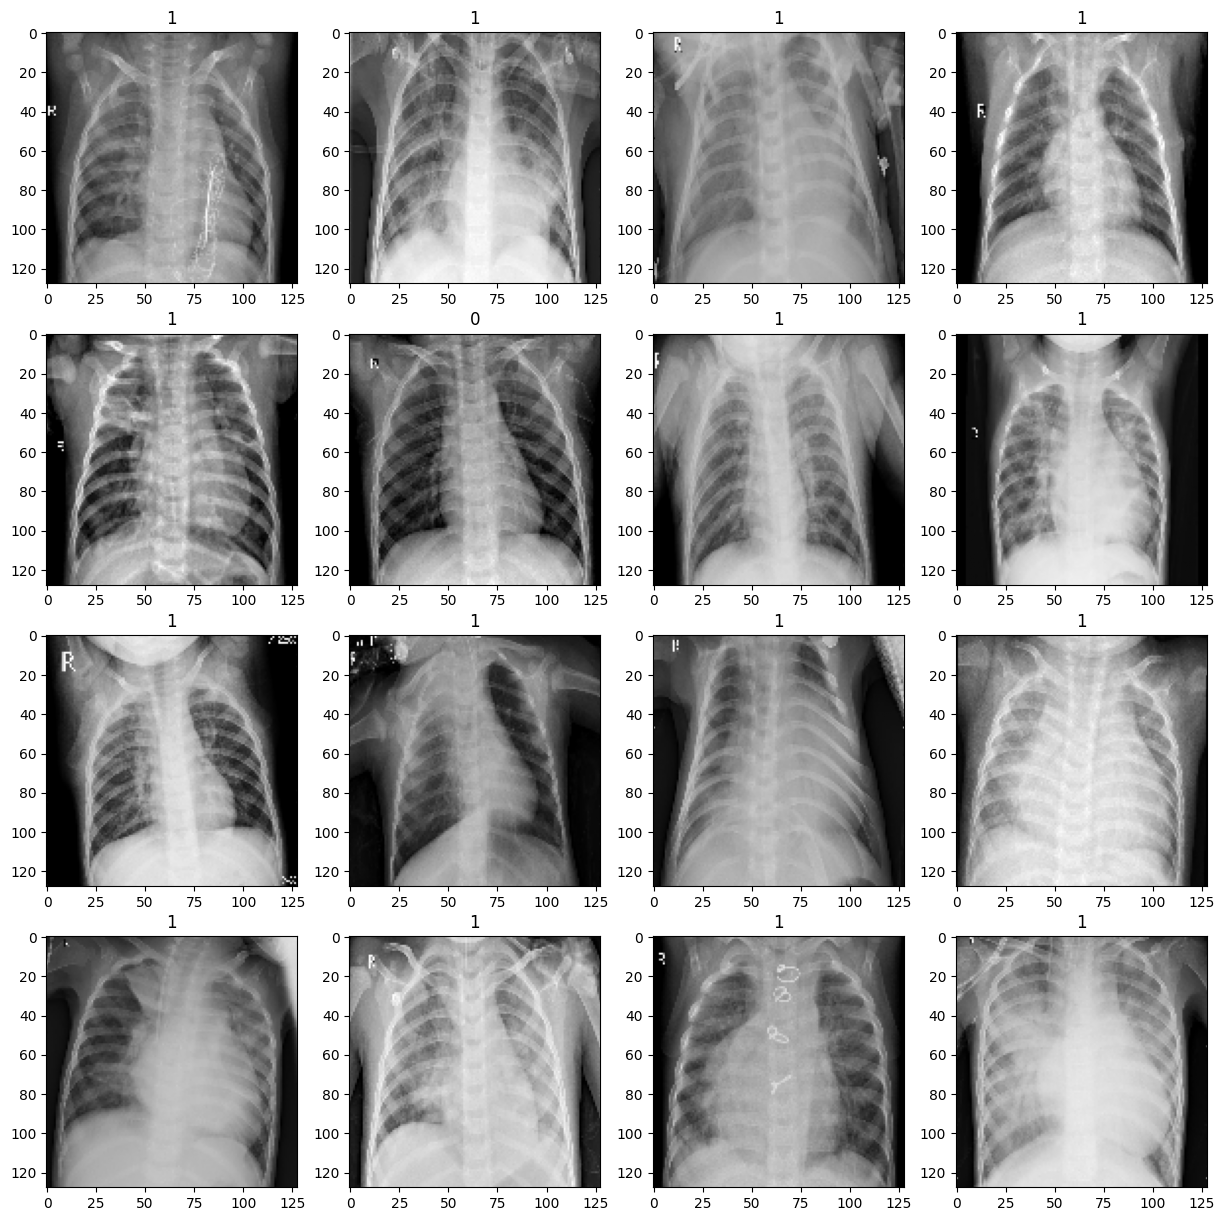

In [7]:
plt.figure(figsize=(15,15))
for n,img in enumerate(np.random.randint(0,len(X),16)):
    plt.subplot(4,4,n+1)
    plt.imshow(X[img],cmap='gray')
    plt.title(y[img])

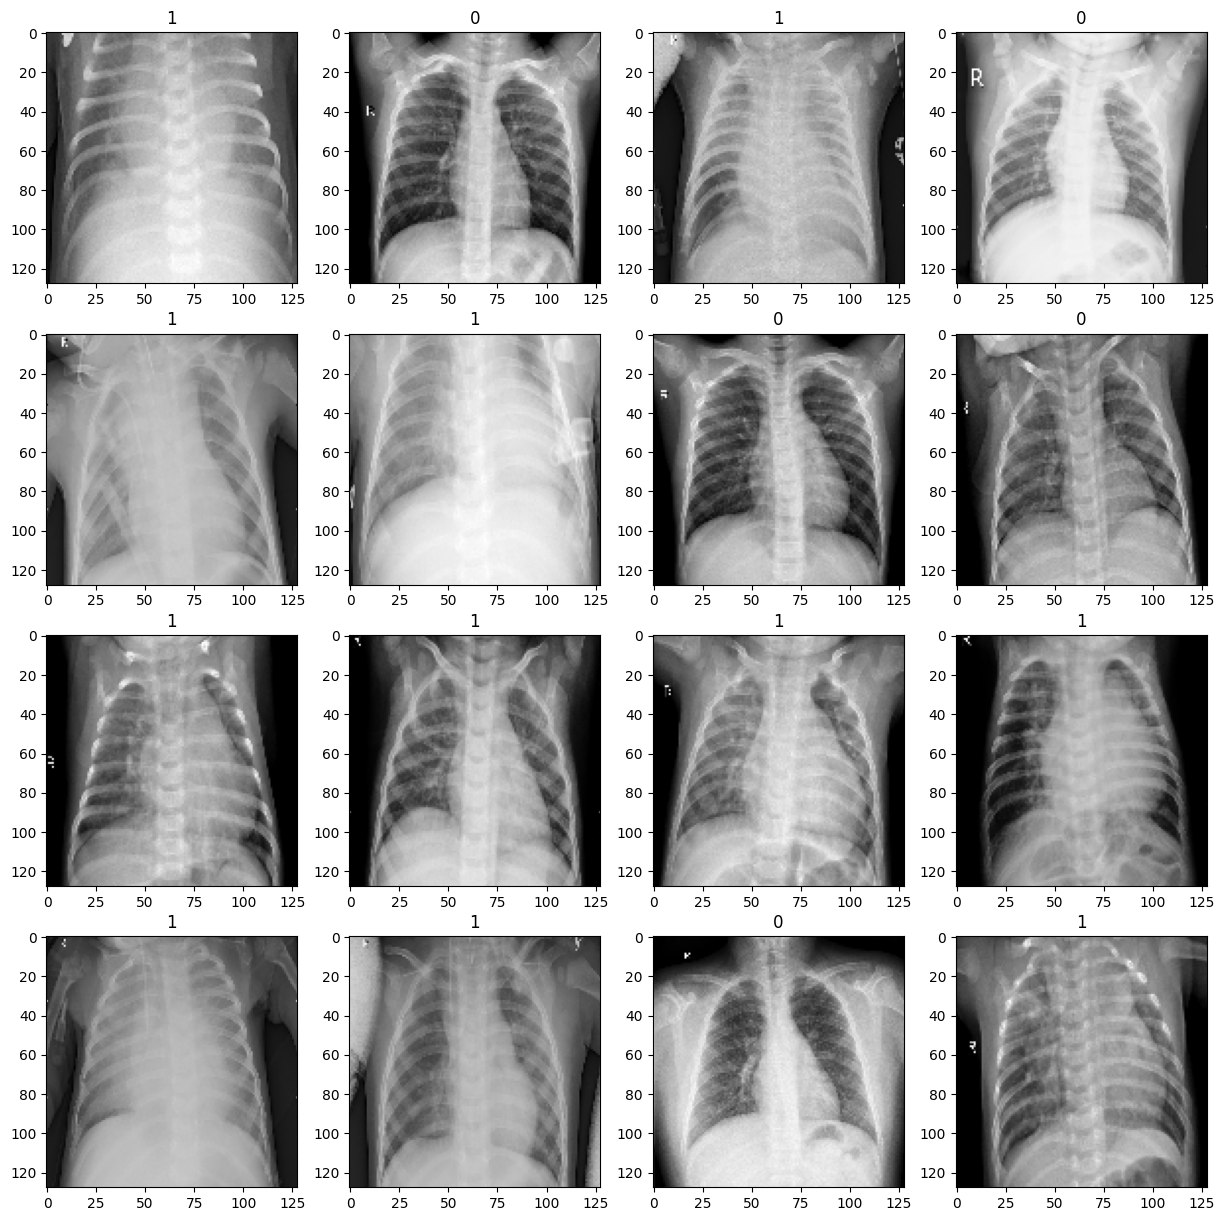

In [8]:
plt.figure(figsize=(15,15))
for n,img in enumerate(np.random.randint(0,len(X),16)):
    plt.subplot(4,4,n+1)
    plt.imshow(X[img],cmap='gray')
    plt.title(y[img])

In [9]:
X_val = []
y_val = []

for cls in os.listdir(val_dir):
    print(cls)
    imgs_paths = gb.glob(val_dir +f"/{cls}/*.jpeg")
    print(len(imgs_paths))

    for img_path in tqdm(imgs_paths):
        img =cv2.imread(img_path)
        img = cv2.resize(img,(224,224))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
        X_val.append(img)
        y_val.append(cls)

PNEUMONIA
8


100%|██████████| 8/8 [00:00<00:00, 82.56it/s]


NORMAL
8


100%|██████████| 8/8 [00:00<00:00, 54.88it/s]


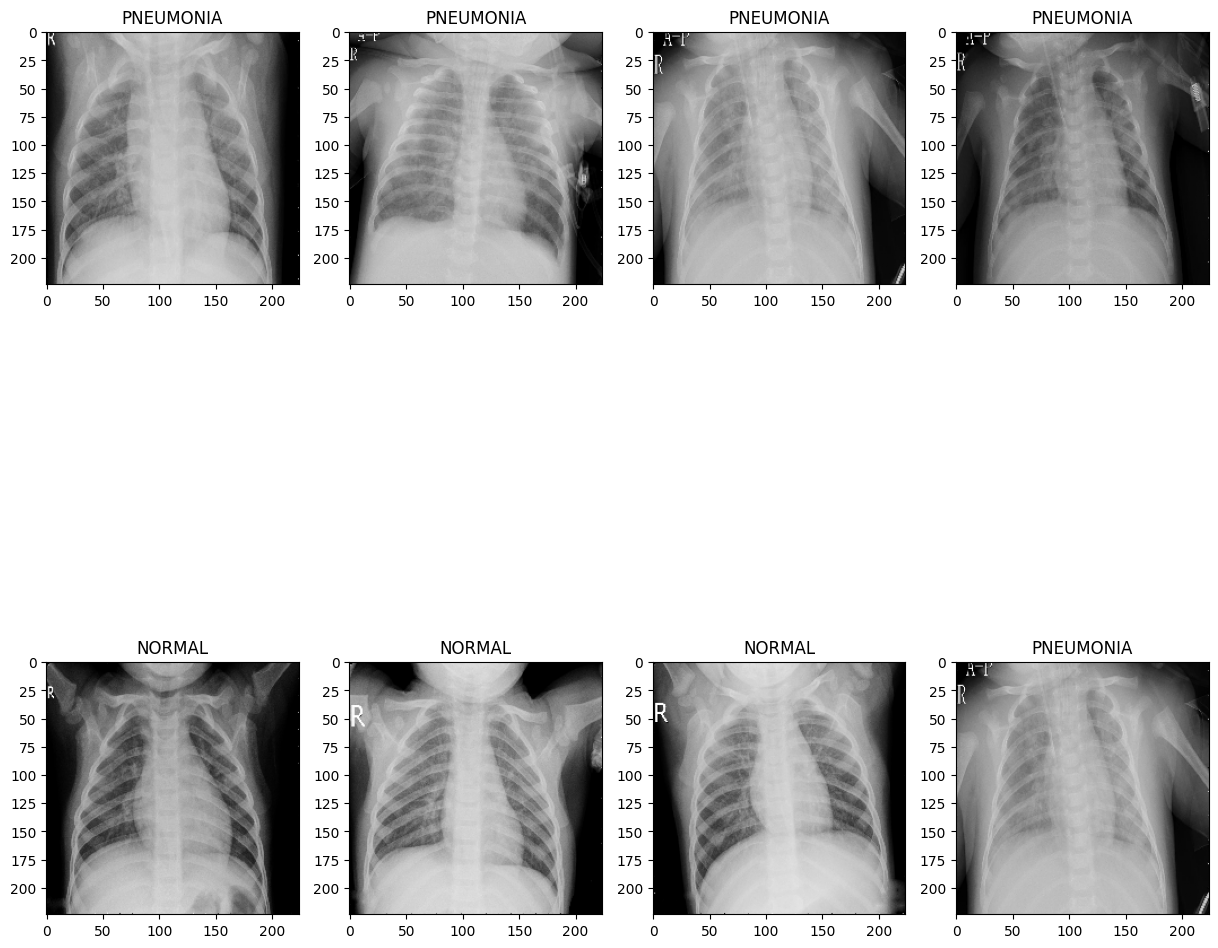

In [10]:
plt.figure(figsize=(15,15))
for n,img in enumerate(np.random.randint(0,len(X_val),8)):
    plt.subplot(2,4,n+1)
    plt.imshow(X_val[img],cmap='gray')
    plt.title(y_val[img])

# 5.ANN Model

## 5.1 Build Model


In [11]:
X_ann = X.reshape(X.shape[0], -1)

print(X_ann.shape)

(5216, 16384)


In [12]:

X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_ann,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
ann_model = Sequential([

    Dense(
        512,
        activation='relu',
        input_shape=(X_train_ann.shape[1],)
    ),

    Dropout(0.5),

    Dense(256, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 5.2 Compile Model


In [14]:
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 5.3 Train Model


In [16]:
history_ann = ann_model.fit(
    X_train_ann,
    y_train_ann,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7570 - loss: 1.3182 - val_accuracy: 0.8970 - val_loss: 0.2454
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8475 - loss: 0.3491 - val_accuracy: 0.8455 - val_loss: 0.3003
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8232 - loss: 0.3486 - val_accuracy: 0.8970 - val_loss: 0.2565
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8331 - loss: 0.3317 - val_accuracy: 0.9341 - val_loss: 0.2493


##5.4 Model Summary

In [17]:
ann_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,562,117 (97.51 MB)

 Trainable params: 8,520,705 (32.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,041,412 (65.01 MB)

##5.5  Plot ANN Accuracy and Loss



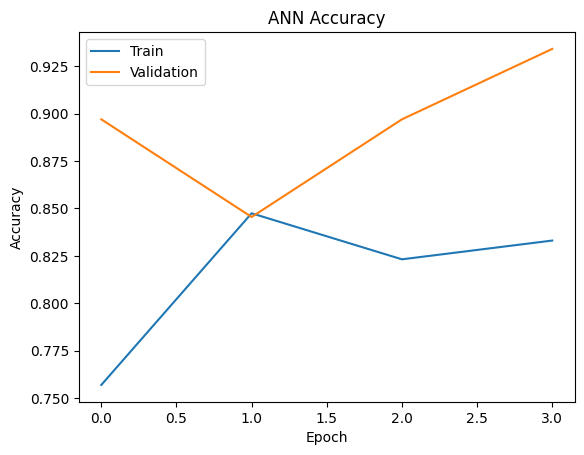

In [19]:
plt.plot(history_ann.history['accuracy'])
plt.plot(history_ann.history['val_accuracy'])

plt.title("ANN Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

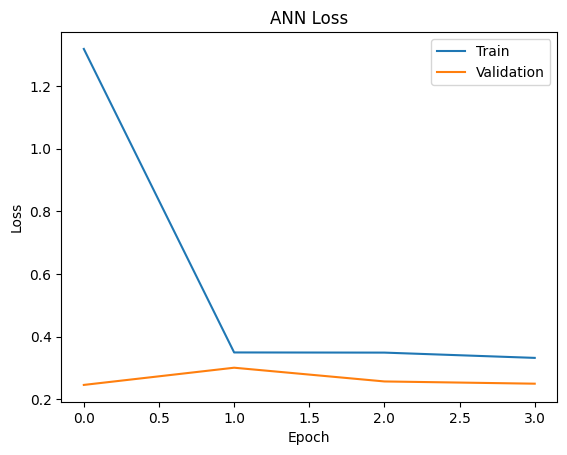

In [20]:
plt.plot(history_ann.history['loss'])
plt.plot(history_ann.history['val_loss'])

plt.title("ANN Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

##5.6 Predict and Confusion Matrix

In [21]:
y_pred_ann = ann_model.predict(X_test_ann)

y_pred_ann = (y_pred_ann > 0.5).astype(int)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


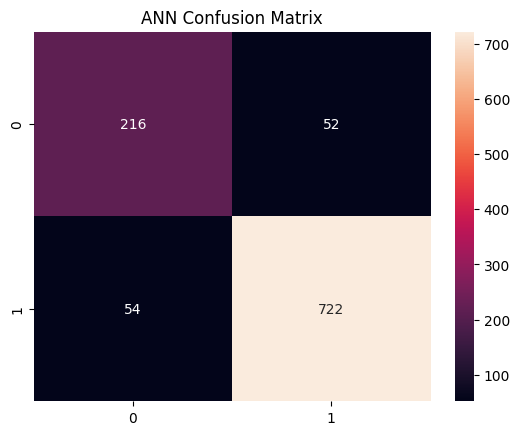

In [22]:
cm_ann = confusion_matrix(y_test_ann, y_pred_ann)

sns.heatmap(cm_ann, annot=True, fmt='d')

plt.title("ANN Confusion Matrix")

plt.show()

In [23]:
print(classification_report(y_test_ann, y_pred_ann))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80       268
           1       0.93      0.93      0.93       776

    accuracy                           0.90      1044
   macro avg       0.87      0.87      0.87      1044
weighted avg       0.90      0.90      0.90      1044



#6.CNN Model



## 6.1 Build Model


In [24]:
X_cnn = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print(X_cnn.shape)

(5216, 128, 128, 1)


In [25]:

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 6.2 Compile Model


In [26]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 1)
    ),

    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 6.3 Train Model


In [28]:
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,

    validation_split=0.2,

    epochs=20,

    batch_size=32,

    callbacks=[early_stop]
)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.8610 - loss: 0.3211 - val_accuracy: 0.9293 - val_loss: 0.1676
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9434 - loss: 0.1508 - val_accuracy: 0.9545 - val_loss: 0.1140
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9547 - loss: 0.1219 - val_accuracy: 0.9653 - val_loss: 0.1018
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9634 - loss: 0.0993 - val_accuracy: 0.9689 - val_loss: 0.0701
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9718 - loss: 0.0818 - val_accuracy: 0.9760 - val_loss: 0.0839
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9688 - loss: 0.0840 - val_accuracy: 0.9772 - val_loss: 0.0659
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9793 - loss: 0.0598 - val_accuracy: 0.9796 - val_loss: 0.0669
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9799 - loss: 0.0575 - val_acc

##6.4 Model Summary

In [29]:
cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,912,581 (37.81 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,608,388 (25.21 MB)

##6.5  Plot ANN Accuracy and Loss


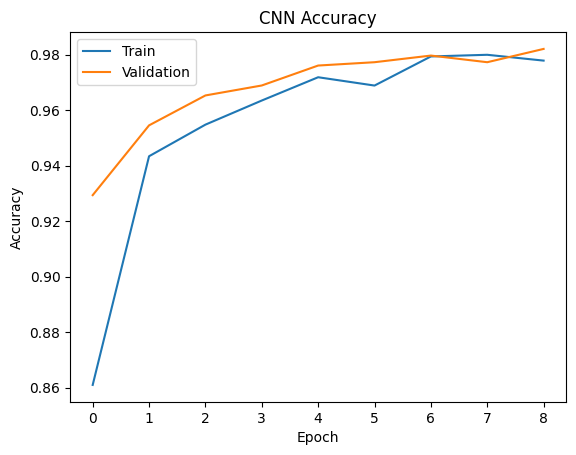

In [30]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

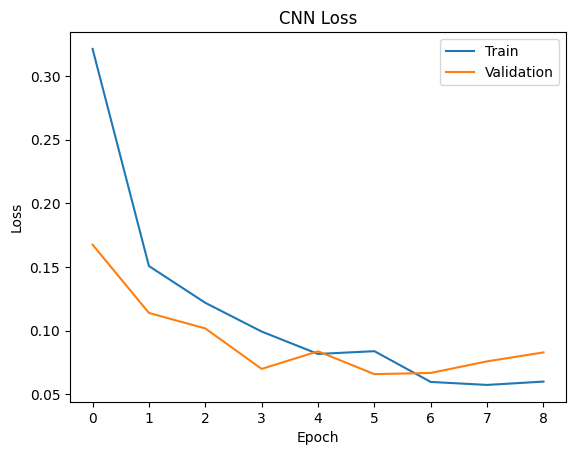

In [31]:
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title("CNN Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

##6.6 Predict and Confusion Matrix

In [32]:
y_pred_cnn = cnn_model.predict(X_test_cnn)

y_pred_cnn = (y_pred_cnn > 0.5).astype(int)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


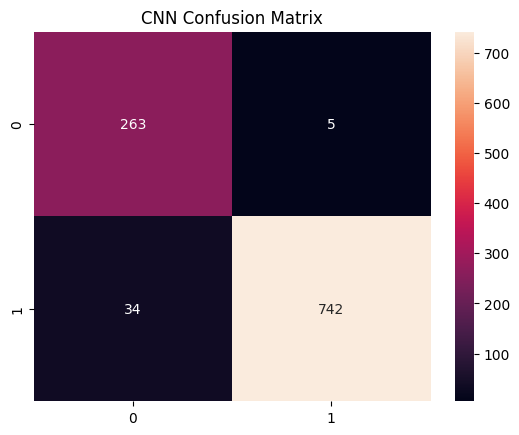

In [33]:
cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)

sns.heatmap(cm_cnn, annot=True, fmt='d')

plt.title("CNN Confusion Matrix")

plt.show()

In [34]:
print(classification_report(y_test_cnn, y_pred_cnn))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       268
           1       0.99      0.96      0.97       776

    accuracy                           0.96      1044
   macro avg       0.94      0.97      0.95      1044
weighted avg       0.97      0.96      0.96      1044



# 6. Prediction


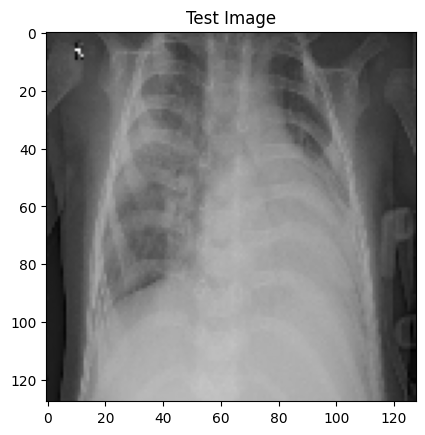

In [35]:
sample = X_test_cnn[0]

plt.imshow(sample.squeeze(), cmap='gray')

plt.title("Test Image")

plt.show()

In [36]:
prediction = cnn_model.predict(
    np.expand_dims(sample, axis=0)
)

print(prediction)

if prediction > 0.5:
    print("PNEUMONIA")
else:
    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
[[0.9999975]]
PNEUMONIA


# 7. Bonus - Transfer Learning

##7.1 Convert Gray Images to RGB

In [37]:
X_rgb = []

for img in X:

    rgb = cv2.cvtColor(
        (img * 255).astype(np.uint8),
        cv2.COLOR_GRAY2RGB
    )

    X_rgb.append(rgb)

X_rgb = np.array(X_rgb)

print(X_rgb.shape)

(5216, 128, 128, 3)


##7.2 Split Data

In [38]:
X_train_tl, X_test_tl, y_train_tl, y_test_tl = train_test_split(
    X_rgb,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##7.3 Load MobileNetV2

In [39]:
base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(128,128,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##7.4 Freeze Base Model

In [40]:
base_model.trainable = False

##7.5 Build Transfer Learning Model

In [41]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(1, activation='sigmoid')(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

##7.6 Compile Model

In [42]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#7.7 Train Model

In [43]:
X_train_tl = np.array(X_train_tl)
y_train_tl = np.array(y_train_tl)

X_test_tl = np.array(X_test_tl)
y_test_tl = np.array(y_test_tl)

In [44]:
history_tl = transfer_model.fit(

    X_train_tl,
    y_train_tl,

    validation_split=0.2,

    epochs=20,

    batch_size=32,

    callbacks=[early_stop]
)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 271ms/step - accuracy: 0.8574 - loss: 0.3148 - val_accuracy: 0.9030 - val_loss: 0.2413
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9005 - loss: 0.2316 - val_accuracy: 0.8994 - val_loss: 0.2233
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9035 - loss: 0.2242 - val_accuracy: 0.9090 - val_loss: 0.2097


#7.8 Plot Accuracy and Loss


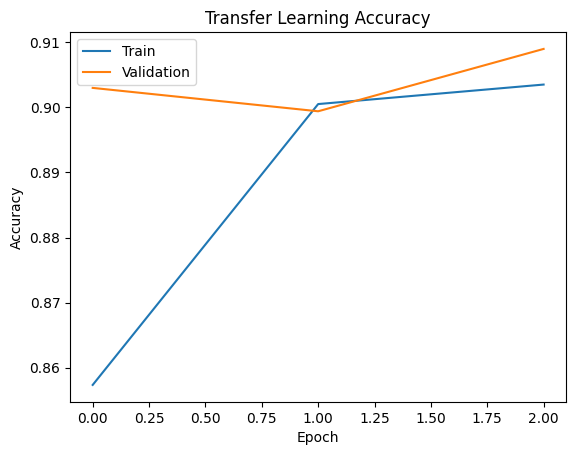

In [45]:
plt.plot(history_tl.history['accuracy'])
plt.plot(history_tl.history['val_accuracy'])

plt.title("Transfer Learning Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

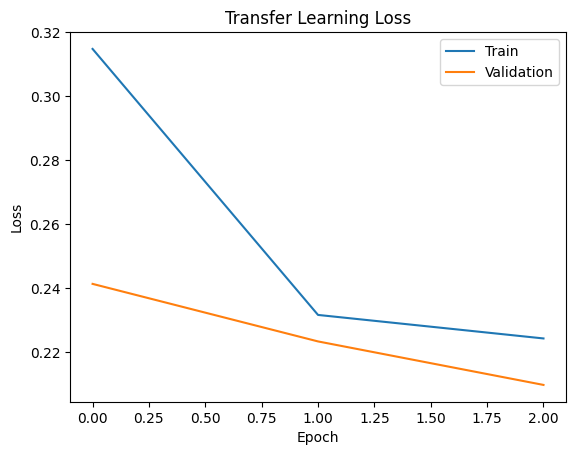

In [46]:
plt.plot(history_tl.history['loss'])
plt.plot(history_tl.history['val_loss'])

plt.title("Transfer Learning Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

##7.9 Predict and Confusion Matrix

In [47]:
y_pred_tl = transfer_model.predict(X_test_tl)

y_pred_tl = (y_pred_tl > 0.5).astype(int)

33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 377ms/step


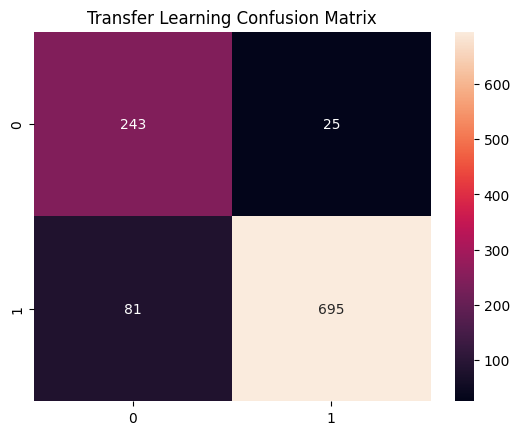

In [48]:
cm_tl = confusion_matrix(y_test_tl, y_pred_tl)

sns.heatmap(cm_tl, annot=True, fmt='d')

plt.title("Transfer Learning Confusion Matrix")

plt.show()

In [49]:
print(classification_report(y_test_tl, y_pred_tl))

              precision    recall  f1-score   support

           0       0.75      0.91      0.82       268
           1       0.97      0.90      0.93       776

    accuracy                           0.90      1044
   macro avg       0.86      0.90      0.88      1044
weighted avg       0.91      0.90      0.90      1044



##7.9 Model summary

In [50]:
transfer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

#8 Final Comparison

In [51]:
results = pd.DataFrame({

    'Model': ['ANN', 'CNN', 'Transfer Learning'],

    'Accuracy': [

        max(history_ann.history['val_accuracy']),

        max(history_cnn.history['val_accuracy']),

        max(history_tl.history['val_accuracy'])
    ]
})

results

,Model,Accuracy
0,ANN,0.934132
1,CNN,0.982036
2,Transfer Learning,0.908982


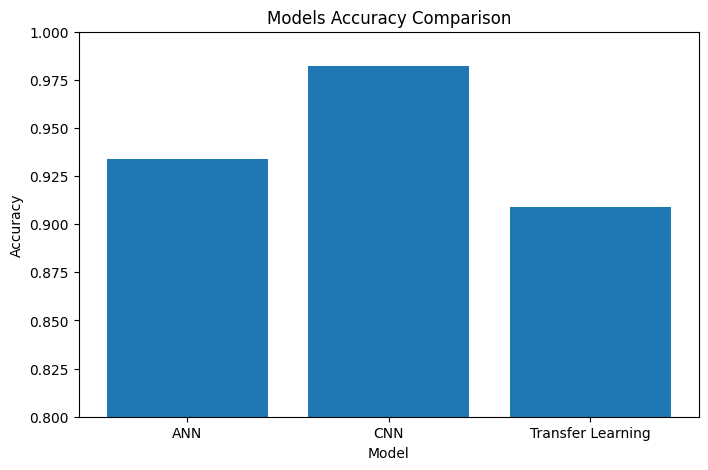

In [52]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['Accuracy'])

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Models Accuracy Comparison")

plt.ylim(0.8,1.0)

plt.show()

## Bouns - Gradio Deployment

In [53]:
import gradio as gr # مكتبه لانشاء واجهه استخدام

In [54]:
classes = ['NORMAL', 'PNEUMONIA']

def predict_xray(image):

    # Resize
    image = cv2.resize(image, (128,128))

    # Convert Gray to RGB
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    # Normalize
    image = image / 255.0

    # Expand Dimensions
    image = np.expand_dims(image, axis=0) # الديمنشن بتاع الباتش

    # Prediction
    prediction = transfer_model.predict(image)

    probability = float(prediction[0][0])

    if probability > 0.5:
        result = "PNEUMONIA"
    else:
        result = "NORMAL"

    return {
        "NORMAL": 1 - probability,
        "PNEUMONIA": probability
    }

In [55]:
interface = gr.Interface(

    fn=predict_xray,

    inputs=gr.Image(
        type="numpy",
        image_mode="L",
        label="Upload X-Ray Image"
    ),

    outputs=gr.Label(
        label="Prediction"
    ),

    title="AI Chest X-Ray Detector",

    description="""
    Deep Learning project using:

    • ANN
    • CNN
    • Transfer Learning

    Upload a chest X-ray image for prediction.
    """,

    theme="soft"
)

In [56]:
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://93ed80846c48621518.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
